In [91]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [92]:


def generate_massive_dataset(target_size=1500):
    data = set()

    # 1. Subject Groups mapped to their exact Urdu grammatical conjugations
    # Format: (English Subject, Urdu Subject)
    masc_sing = [("he", "wo"), ("ali", "ali"), ("my brother", "mera bhai"), 
                 ("the boy", "larka"), ("bilal", "bilal")]
    fem_sing = [("she", "wo"), ("sara", "sara"), ("my sister", "meri behan"), 
                ("the girl", "larki"), ("ayesha", "ayesha")]
    first_person = [("I", "main")]
    plurals = [("we", "hum"), ("they", "wo"), ("the boys", "larkay"), 
               ("the students", "talaba"), ("my friends", "mere dost")]

    # 2. Action Verbs mapping
    # Format: (English Base, English 's', Urdu Root)
    actions = [
        (("play", "plays", "khel"), [
            ("cricket", "cricket"), ("hockey", "hockey"), ("football", "football"), 
            ("tennis", "tennis"), ("games", "games"), ("chess", "shatranj")
        ]),
        (("eat", "eats", "kha"), [
            ("biryani", "biryani"), ("food", "khana"), ("apples", "saib"), 
            ("mangoes", "aam"), ("meat", "gosht"), ("rice", "chawal")
        ]),
        (("read", "reads", "parh"), [
            ("research papers", "research papers"), ("books", "kitabein"), 
            ("a book", "ek kitab"), ("news", "khabrein"), ("articles", "articles"),
            ("notes", "notes"), ("stories", "kahaniyan")
        ]),
        (("learn", "learns", "seekh"), [
            ("deep learning", "deep learning"), ("python", "python"), 
            ("math", "math"), ("science", "science"), ("english", "english"), 
            ("urdu", "urdu"), ("coding", "coding")
        ]),
        (("write", "writes", "likh"), [
            ("code", "code"), ("letters", "khat"), ("books", "kitabein"), 
            ("notes", "notes"), ("emails", "emails"), ("poems", "nazmein")
        ]),
        (("drink", "drinks", "pee"), [
            ("tea", "chai"), ("water", "pani"), ("coffee", "coffee"), 
            ("milk", "doodh"), ("juice", "juice"), ("soup", "soup")
        ]),
        (("watch", "watches", "dekh"), [
            ("movies", "filmein"), ("matches", "matches"), ("tv", "tv"), 
            ("birds", "parinday"), ("videos", "videos"), ("the sky", "asman")
        ]),
        (("buy", "buys", "khareed"), [
            ("a car", "ek gari"), ("a phone", "ek phone"), ("books", "kitabein"), 
            ("clothes", "kapray"), ("a bag", "ek bag"), ("shoes", "jootay")
        ]),
        (("sell", "sells", "bech"), [
            ("a car", "ek gari"), ("a phone", "ek phone"), ("books", "kitabein"), 
            ("clothes", "kapray"), ("a bag", "ek bag"), ("shoes", "jootay")
        ]),
        (("make", "makes", "bana"), [
            ("food", "khana"), ("tea", "chai"), ("coffee", "coffee"), 
            ("a model", "ek model"), ("a project", "ek project")
        ])
    ]

    # Generate Habitual Sentences (Present Tense)
    for (e_base, e_s, u_root), objects in actions:
        for e_obj, u_obj in objects:
            # First Person (I play -> main khelta hoon)
            for e_sub, u_sub in first_person:
                data.add((f"{e_sub} {e_base} {e_obj}", f"{u_sub} {u_obj} {u_root}ta hoon"))
            # Masc Singular (He plays -> wo khelta hai)
            for e_sub, u_sub in masc_sing:
                data.add((f"{e_sub} {e_s} {e_obj}", f"{u_sub} {u_obj} {u_root}ta hai"))
            # Fem Singular (She plays -> wo khelti hai)
            for e_sub, u_sub in fem_sing:
                data.add((f"{e_sub} {e_s} {e_obj}", f"{u_sub} {u_obj} {u_root}ti hai"))
            # Plurals (We play -> hum khelte hain)
            for e_sub, u_sub in plurals:
                data.add((f"{e_sub} {e_base} {e_obj}", f"{u_sub} {u_obj} {u_root}te hain"))

    # 3. States (Like / Need / Have) - These use different Urdu pronouns (mujhe, usey, humein)
    states = [
        # LIKE
        ([("I", "mujhe"), ("he", "usey"), ("she", "usey"), ("we", "humein"), 
          ("they", "unhein"), ("ali", "ali ko"), ("sara", "sara ko")],
         "like", "likes", "pasand hai",
         [("deep learning", "deep learning"), ("python", "python"), ("cricket", "cricket"), 
          ("biryani", "biryani"), ("tea", "chai"), ("pakistan", "pakistan")]),

        # NEED
        ([("I", "mujhe"), ("he", "usey"), ("she", "usey"), ("we", "humein"), 
          ("they", "unhein"), ("bilal", "bilal ko")],
         "need", "needs", "chahiye",
         [("a scholarship", "scholarship"), ("water", "pani"), ("food", "khana"), 
          ("a pen", "ek pen"), ("a car", "ek gari"), ("money", "paise")]),
    ]

    for subjects, e_verb_base, e_verb_s, u_verb, objects in states:
        for e_sub, u_sub in subjects:
            verb = e_verb_base if e_sub in ["I", "we", "they"] else e_verb_s
            for e_obj, u_obj in objects:
                data.add((f"{e_sub} {verb} {e_obj}", f"{u_sub} {u_obj} {u_verb}"))

    # 4. Descriptives (The Noun is Adjective)
    nouns = [
        ("the sky", "asman"), ("the weather", "mausam"), ("the sun", "sooraj"), 
        ("the tree", "darakht"), ("the car", "gari"), ("the model", "model"), 
        ("the cat", "billi"), ("the dog", "kutta"), ("math", "math"), 
        ("science", "science"), ("ai", "ai"), ("water", "pani"), ("the code", "code"),
        ("the book", "kitab"), ("the house", "ghar")
    ]
    adjectives = [
        ("beautiful", "khubsurat"), ("smart", "hoshiyar"), ("good", "acha"), 
        ("fast", "tez"), ("blue", "neela"), ("tall", "lamba"), 
        ("interesting", "dilchasp"), ("essential", "zaroori"), 
        ("amazing", "hairan kun"), ("black", "kala"), ("new", "naya"),
        ("old", "purana"), ("big", "bara")
    ]

    for enoun, unoun in nouns:
        for eadj, uadj in adjectives:
            data.add((f"{enoun} is {eadj}", f"{unoun} {uadj} hai"))

    # Convert to list, shuffle, and sample
    data_list = list(data)
    random.shuffle(data_list)
    
    # Ensure we have the original test sentences
    mandatory = [
        ("I live in Pakistan", "main pakistan mein rehta hoon"),
        ("I like deep learning", "mujhe deep learning pasand hai"),
        ("I am taking the academic test", "main academic test de raha hoon"),
        ("roses are beautiful", "gulab khubsurat hain")
    ]
    
    for m in mandatory:
        if m not in data_list:
            data_list.insert(0, m)

    # Trim to target size (e.g., exactly 1500 sentences)
    final_dataset = data_list[:target_size]
    return final_dataset

# Generate and write to file
dataset = generate_massive_dataset(target_size=1500)


print(f"Success! Generated exactly {len(dataset)} sentence pairs.")

Success! Generated exactly 1252 sentence pairs.


In [93]:
dataset

[('roses are beautiful', 'gulab khubsurat hain'),
 ('I am taking the academic test', 'main academic test de raha hoon'),
 ('I live in Pakistan', 'main pakistan mein rehta hoon'),
 ('sara writes letters', 'sara khat likhti hai'),
 ('my sister reads research papers', 'meri behan research papers parhti hai'),
 ('the boy plays tennis', 'larka tennis khelta hai'),
 ('the tree is fast', 'darakht tez hai'),
 ('he writes letters', 'wo khat likhta hai'),
 ('he sells shoes', 'wo jootay bechta hai'),
 ('my friends sell a bag', 'mere dost ek bag bechte hain'),
 ('the boy writes code', 'larka code likhta hai'),
 ('the boy learns english', 'larka english seekhta hai'),
 ('the students play tennis', 'talaba tennis khelte hain'),
 ('the sun is beautiful', 'sooraj khubsurat hai'),
 ('we drink tea', 'hum chai peete hain'),
 ('he writes emails', 'wo emails likhta hai'),
 ('my sister buys shoes', 'meri behan jootay khareedti hai'),
 ('the boys eat rice', 'larkay chawal khate hain'),
 ('the boys watch movi

In [94]:
def build_vocab(sentences):
    vocab = {"<SOS>": 0, "<EOS>": 1}
    for sentence in sentences:
        for word in sentence.lower().split():
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab

english_sentences = [pair[0] for pair in raw_data]
urdu_sentences = [pair[1] for pair in raw_data]

eng_vocab = build_vocab(english_sentences)
urdu_vocab = build_vocab(urdu_sentences)
urdu_idx_to_word = {idx: word for word, idx in urdu_vocab.items()}

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

In [95]:

class Embedding:
    def __init__(self, vocab_size, embed_dim):
        self.E = np.random.randn(vocab_size, embed_dim) * 0.1
        self.grad_E = np.zeros_like(self.E)

    def forward(self, idx):
        return self.E[idx]
        
    def backward(self, d_out, idx):
        self.grad_E[idx] += d_out[0]

    def update_weights(self, lr):
        self.E -= lr * self.grad_E
        self.grad_E.fill(0)


In [96]:
class LSTM:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        concat_dim = input_dim + hidden_dim

        self.W_f, self.b_f = self.gate(concat_dim, hidden_dim, forget_bias=True) 
        self.W_i, self.b_i = self.gate(concat_dim, hidden_dim) 
        self.W_c, self.b_c = self.gate(concat_dim, hidden_dim) 
        self.W_o, self.b_o = self.gate(concat_dim, hidden_dim) 
        
        self.zero_grad()

    def zero_grad(self):
        self.grad_W_f = np.zeros_like(self.W_f)
        self.grad_b_f = np.zeros_like(self.b_f)
        self.grad_W_i = np.zeros_like(self.W_i)
        self.grad_b_i = np.zeros_like(self.b_i)
        self.grad_W_c = np.zeros_like(self.W_c)
        self.grad_b_c = np.zeros_like(self.b_c)
        self.grad_W_o = np.zeros_like(self.W_o)
        self.grad_b_o = np.zeros_like(self.b_o)

    def gate(self, input_size, output_size, forget_bias=False):
        W = np.random.randn(input_size, output_size) * 0.1
        b = np.random.randn(1, output_size) * 0.1
        if forget_bias:
            b += 1.0 
        return W, b

    def forward(self, X, prev_c, prev_h):
        xh = np.concatenate([X, prev_h], axis=1)
        
        f = sigmoid(xh @ self.W_f + self.b_f)
        i = sigmoid(xh @ self.W_i + self.b_i)
        c_tilde = np.tanh(xh @ self.W_c + self.b_c)
        o = sigmoid(xh @ self.W_o + self.b_o)
        
        c_next = f * prev_c + i * c_tilde
        h_next = o * np.tanh(c_next)
        
        cache = (prev_c, prev_h, xh, f, i, c_tilde, o, c_next)
        return c_next, h_next, cache

    def backward(self, dh_next, dc_next, cache):
        prev_c, prev_h, xh, f, i, c_tilde, o, c_next = cache

        do = dh_next * np.tanh(c_next)
        dc_local = dh_next * o * (1 - np.tanh(c_next)**2)
        dc_total = dc_local + dc_next

        df = dc_total * prev_c
        di = dc_total * c_tilde
        dc_tilde = dc_total * i
        dc_prev = dc_total * f

        dz_f = df * f * (1 - f)
        dz_i = di * i * (1 - i)
        dz_c = dc_tilde * (1 - c_tilde**2)
        dz_o = do * o * (1 - o)

        self.grad_W_f += xh.T @ dz_f
        self.grad_b_f += np.sum(dz_f, axis=0, keepdims=True)
        self.grad_W_i += xh.T @ dz_i
        self.grad_b_i += np.sum(dz_i, axis=0, keepdims=True)
        self.grad_W_c += xh.T @ dz_c
        self.grad_b_c += np.sum(dz_c, axis=0, keepdims=True)
        self.grad_W_o += xh.T @ dz_o
        self.grad_b_o += np.sum(dz_o, axis=0, keepdims=True)

        dxh = (dz_f @ self.W_f.T) + (dz_i @ self.W_i.T) + \
              (dz_c @ self.W_c.T) + (dz_o @ self.W_o.T)

        dX = dxh[:, :self.input_dim]
        dprev_h = dxh[:, self.input_dim:]

        return dX, dc_prev, dprev_h

    def update_weights(self, lr):
        self.W_f -= lr * self.grad_W_f
        self.b_f -= lr * self.grad_b_f
        self.W_i -= lr * self.grad_W_i
        self.b_i -= lr * self.grad_b_i
        self.W_c -= lr * self.grad_W_c
        self.b_c -= lr * self.grad_b_c
        self.W_o -= lr * self.grad_W_o
        self.b_o -= lr * self.grad_b_o
        self.zero_grad()


In [97]:
class ANN:
    def __init__(self, hidden_dim, output_vocab_size):
        self.W_y = np.random.randn(hidden_dim, output_vocab_size) * 0.1
        self.b_y = np.random.randn(1, output_vocab_size) * 0.1
        self.zero_grad()

    def zero_grad(self):
        self.grad_W_y = np.zeros_like(self.W_y)
        self.grad_b_y = np.zeros_like(self.b_y)

    def forward(self, h):
        logits = h @ self.W_y + self.b_y
        
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True)) 
        probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        cache = h
        return probabilities, cache
        
    def backward(self, dZ, cache):
        h = cache
        self.grad_W_y += h.T @ dZ
        self.grad_b_y += np.sum(dZ, axis=0, keepdims=True)
        dh = dZ @ self.W_y.T
        return dh

    def update_weights(self, lr):
        self.W_y -= lr * self.grad_W_y
        self.b_y -= lr * self.grad_b_y
        self.zero_grad()


In [98]:

class CrossEntropyLoss:
    def forward(self, predictions, targets):
        eps = 1e-9
        seq_len = targets.shape[0] 
        loss = -np.sum(targets * np.log(predictions + eps)) / seq_len
        return loss

In [102]:
english_sentences = [pair[0] for pair in dataset]
urdu_sentences = [pair[1] for pair in dataset]

# 2. Build the NEW vocabularies based on the massive dataset
eng_vocab = build_vocab(english_sentences)
urdu_vocab = build_vocab(urdu_sentences)
urdu_idx_to_word = {idx: word for word, idx in urdu_vocab.items()}

print(f"Vocabulary built! English words: {len(eng_vocab)} | Urdu words: {len(urdu_vocab)}")

Vocabulary built! English words: 129 | Urdu words: 143


# **Vanilla Encoder Decoder**

In [46]:
class VanillaSeq2seq:
    def __init__(self, eng_vocab_size, urdu_vocab_size, embed_dim, hidden_dim):
        self.hidden_dim = hidden_dim
        
        self.src_embed = Embedding(eng_vocab_size, embed_dim)
        self.tgt_embed = Embedding(urdu_vocab_size, embed_dim)
        
        # Both LSTMs now only take embed_dim as input
        self.encoder = LSTM(embed_dim, hidden_dim)
        self.decoder = LSTM(embed_dim, hidden_dim) 
        
        self.ANN = ANN(hidden_dim, urdu_vocab_size)

    def forward(self, src_indices, tgt_indices):
        self.c_s = np.zeros((1, self.hidden_dim))
        self.h_s = np.zeros((1, self.hidden_dim))

        encoder_caches = []
        
        # 1. ENCODER PASS
        for idx in src_indices:
            x_t = self.src_embed.forward(idx)[np.newaxis, :] 
            self.c_s, self.h_s, enc_cache = self.encoder.forward(x_t, self.c_s, self.h_s)
            encoder_caches.append((idx, enc_cache))
            
        # 2. THE BRIDGE (Pass final encoder state to decoder)
        dec_c_s = self.c_s 
        dec_h_s = self.h_s

        outputs = [] 
        decoder_caches = []
        
        # 3. DECODER PASS
        for i, idx in enumerate(tgt_indices[:-1]):
            # Input is ONLY the embedded word, no context vector!
            y_t = self.tgt_embed.forward(idx)[np.newaxis, :] 
            
            dec_c_s, dec_h_s, dec_cache = self.decoder.forward(y_t, dec_c_s, dec_h_s)
            y_hat, ann_cache = self.ANN.forward(dec_h_s)
            
            outputs.append(y_hat)
            decoder_caches.append((idx, dec_cache, ann_cache))
            
        caches = (encoder_caches, decoder_caches)
        return np.concatenate(outputs, axis=0), caches

    def backward(self, predictions, targets, caches):
        encoder_caches, decoder_caches = caches
        seq_len = targets.shape[0]

        dh_dec_next = np.zeros((1, self.hidden_dim))
        dc_dec_next = np.zeros((1, self.hidden_dim))

        # ----------------------------------------
        # BPTT: DECODER
        # ----------------------------------------
        for t in reversed(range(len(decoder_caches))):
            idx, dec_cache, ann_cache = decoder_caches[t]
            
            dZ = (predictions[t] - targets[t])[np.newaxis, :] / seq_len
            dh_ann = self.ANN.backward(dZ, ann_cache)
            dh_dec_total = dh_ann + dh_dec_next
            
            dY_t, dc_dec_next, dh_dec_next = self.decoder.backward(dh_dec_total, dc_dec_next, dec_cache)
            
            # Target Embedding backward
            self.tgt_embed.backward(dY_t, idx)

        # ----------------------------------------
        # THE BRIDGE (Backward)
        # ----------------------------------------
        # The gradients flowing out of the very first decoder step 
        # go directly into the very last encoder step!
        dh_enc_next = dh_dec_next
        dc_enc_next = dc_dec_next
        
        # ----------------------------------------
        # BPTT: ENCODER
        # ----------------------------------------
        for t in reversed(range(len(encoder_caches))):
            idx, enc_cache = encoder_caches[t]
            
            # Encoder backward
            dX_t, dc_enc_next, dh_enc_next = self.encoder.backward(dh_enc_next, dc_enc_next, enc_cache)
            
            # Source Embedding backward
            self.src_embed.backward(dX_t, idx)
        
    def update_weights(self, lr):
        self.src_embed.update_weights(lr)
        self.tgt_embed.update_weights(lr)
        self.encoder.update_weights(lr)
        self.decoder.update_weights(lr)
        self.ANN.update_weights(lr)

In [49]:



# 3. Now initialize your model with the updated vocab sizes
embed_dim = 16
hidden_dim = 32
model = VanillaSeq2seq(len(eng_vocab), len(urdu_vocab), embed_dim, hidden_dim)
criterion = CrossEntropyLoss()

epochs = 1000
learning_rate = 0.1

print("Starting Manual NumPy BPTT Training...\n")

for epoch in range(epochs):
    epoch_loss = 0
    
    for eng_sent, urdu_sent in dataset:
        src_indices = [eng_vocab[w] for w in eng_sent.lower().split()]
        tgt_indices = [urdu_vocab["<SOS>"]] + [urdu_vocab[w] for w in urdu_sent.lower().split()] + [urdu_vocab["<EOS>"]]
        
        predictions, caches = model.forward(src_indices, tgt_indices)
        
        target_words_to_predict = tgt_indices[1:]
        Y_one_hot = np.zeros((len(target_words_to_predict), len(urdu_vocab)))
        for i, word_idx in enumerate(target_words_to_predict):
            Y_one_hot[i, word_idx] = 1.0
            
        loss = criterion.forward(predictions, Y_one_hot)
        epoch_loss += loss # loss is scalar now
        
        model.backward(predictions, Y_one_hot, caches)
        model.update_weights(lr=learning_rate)
        
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Average Loss: {(epoch_loss/len(raw_data)):.4f}")


Vocabulary built! English words: 129 | Urdu words: 143
Starting Manual NumPy BPTT Training...

Epoch 50/1000 | Average Loss: 0.5962
Epoch 100/1000 | Average Loss: 0.1889
Epoch 150/1000 | Average Loss: 0.1087
Epoch 200/1000 | Average Loss: 0.0756
Epoch 250/1000 | Average Loss: 0.0575
Epoch 300/1000 | Average Loss: 0.0462
Epoch 350/1000 | Average Loss: 0.0386
Epoch 400/1000 | Average Loss: 0.0331
Epoch 450/1000 | Average Loss: 0.0289
Epoch 500/1000 | Average Loss: 0.0257
Epoch 550/1000 | Average Loss: 0.0231
Epoch 600/1000 | Average Loss: 0.0209
Epoch 650/1000 | Average Loss: 0.0192
Epoch 700/1000 | Average Loss: 0.0177
Epoch 750/1000 | Average Loss: 0.0164
Epoch 800/1000 | Average Loss: 0.0152
Epoch 850/1000 | Average Loss: 0.0143
Epoch 900/1000 | Average Loss: 0.0134
Epoch 950/1000 | Average Loss: 0.0126
Epoch 1000/1000 | Average Loss: 0.0120


In [50]:
# Inference Function for Vanilla Sequence-to-Sequence
def translate_vanilla(model, english_sentence, max_length=15):
    words = english_sentence.lower().split()
    src_indices = [eng_vocab[w] for w in words if w in eng_vocab]
    
    # If a word is entirely unknown, we skip it (or ideally use an UNK token). 
    if not src_indices:
        return ""
        
    model.c_s = np.zeros((1, model.hidden_dim))
    model.h_s = np.zeros((1, model.hidden_dim))

    # --- ENCODER PASS ---
    for idx in src_indices:
        x_t = model.src_embed.forward(idx)[np.newaxis, :] 
        model.c_s, model.h_s, _ = model.encoder.forward(x_t, model.c_s, model.h_s)
        
    # THE BRIDGE: model.c_s and model.h_s currently hold the final encoder state (Context Vector).
    # We pass them directly into the decoder.

    predicted_words = []
    current_word_idx = urdu_vocab["<SOS>"]
    
    # --- DECODER PASS ---
    for t in range(max_length):
        # Input is ONLY the embedded word
        y_t = model.tgt_embed.forward(current_word_idx)[np.newaxis, :]
        
        # Forward pass through decoder LSTM using the carried-over c_s and h_s
        model.c_s, model.h_s, _ = model.decoder.forward(y_t, model.c_s, model.h_s) 
        
        # Output probabilities
        probabilities, _ = model.ANN.forward(model.h_s) 
        
        best_guess_idx = int(np.argmax(probabilities, axis=1)[0])
        
        if best_guess_idx == urdu_vocab["<EOS>"]:
            break
            
        predicted_words.append(urdu_idx_to_word[best_guess_idx])
        current_word_idx = best_guess_idx

    return " ".join(predicted_words)

In [67]:
text = "she loves python"
tran = translate_vanilla(model, text)
print("Input:", text)
print("Output:", tran)

Input: she loves python
Output: wo python seekhti hai


In [60]:
test_data = [
    # Mixing habitual actions with different subjects/objects
    ("ali reads books", "ali kitabein parhta hai"),
    ("sara makes tea", "sara chai banati hai"),
    ("we buy a car", "hum ek gari khareedte hain"),
    ("they drink water", "wo pani peete hain"),
    ("I watch birds", "main parinday dekhta hoon"),
    ("the boy plays hockey", "larka hockey khelta hai"),
    ("my sister learns coding", "meri behan coding seekhti hai"),
    
    # Mixing states (likes/needs/have)
    ("he likes python", "usey python pasand hai"),
    ("sara needs money", "sara ko paise chahiye"),
    ("I have books", "mere paas kitabein hain"),
    ("my brother needs a phone", "mere bhai ko ek phone chahiye"),
    
    # Mixing descriptives
    ("the cat is beautiful", "billi khubsurat hai"),
    ("the code is new", "code naya hai"),
    ("math is amazing", "math hairan kun hai"),
    ("the weather is cold", "mausam thanda hai") # Note: Ensure 'cold'/'thanda' is in vocab, if not, swap for 'good'/'acha'
]

# Quick vocabulary check to prevent KeyError during testing
# Let's replace the last one just to be safe with known vocab:
test_data[-1] = ("the weather is good", "mausam acha hai")

In [61]:
def evaluate_model(model, test_data, is_vanilla=True):
    print(f"Evaluating model on {len(test_data)} sentences...")
    exact_matches = 0
    total_target_words = 0
    correct_predicted_words = 0

    for eng_sent, target_urdu in test_data:
        # 1. Translate the sentence
        if is_vanilla:
            predicted_urdu = translate_vanilla(model, eng_sent)
        else:
            predicted_urdu = translate(model, eng_sent) # Your attention translate func
            
        # 2. Exact Match Check
        if predicted_urdu.strip() == target_urdu.strip():
            exact_matches += 1
            
        # 3. Word-Level Check
        pred_words = predicted_urdu.split()
        targ_words = target_urdu.split()
        
        total_target_words += len(targ_words)
        
        # Compare word-by-word up to the length of the shorter sentence
        min_len = min(len(pred_words), len(targ_words))
        for i in range(min_len):
            if pred_words[i] == targ_words[i]:
                correct_predicted_words += 1

    # Calculate percentages
    exact_acc = (exact_matches / len(test_data)) * 100
    word_acc = (correct_predicted_words / total_target_words) * 100

    print("-" * 30)
    print(f"Exact Sentence Match: {exact_acc:.2f}%")
    print(f"Word-Level Accuracy:  {word_acc:.2f}%")
    print("-" * 30)
    
    return exact_acc, word_acc


In [69]:
print("--- EVALUATING VANILLA MODEL ---")
vanilla_exact, vanilla_word = evaluate_model(model, test_data, is_vanilla=True)


--- EVALUATING VANILLA MODEL ---
Evaluating model on 15 sentences...
------------------------------
Exact Sentence Match: 86.67%
Word-Level Accuracy:  85.25%
------------------------------


# Attention Mechanism

In [99]:

class BahdanauAttention:
    def __init__(self, hidden_dim):
        self.W_q = np.random.randn(hidden_dim, hidden_dim) * 0.1
        self.W_k = np.random.randn(hidden_dim, hidden_dim) * 0.1
        self.V = np.random.randn(hidden_dim, 1) * 0.1
        self.zero_grad()

    def zero_grad(self):
        self.grad_W_q = np.zeros_like(self.W_q)
        self.grad_W_k = np.zeros_like(self.W_k)
        self.grad_V = np.zeros_like(self.V)

    def forward(self, query, keys):
        q_proj = query @ self.W_q
        k_proj = keys @ self.W_k
        alignment_features = np.tanh(q_proj + k_proj)
        
        scores = alignment_features @ self.V
        scores = scores.T 
        
        # Softmax
        exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
        attn_weights = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        
        # Context Vector
        context_vector = attn_weights @ keys
        
        cache = (query, keys, alignment_features, scores, attn_weights)
        return context_vector, cache

    def backward(self, dContext, cache):
        query, keys, alignment_features, scores, attn_weights = cache
        
        d_attn_weights = dContext @ keys.T  
        dKeys_from_C = attn_weights.T @ dContext 

        d_scores = attn_weights * (d_attn_weights - np.sum(attn_weights * d_attn_weights, axis=1, keepdims=True))
        d_scores = d_scores.T 

        self.grad_V += alignment_features.T @ d_scores
        d_alignment = d_scores @ self.V.T 

        d_pre_align = d_alignment * (1 - alignment_features**2)

        self.grad_W_k += keys.T @ d_pre_align
        dKeys_from_align = d_pre_align @ self.W_k.T

        self.grad_W_q += query.T @ np.sum(d_pre_align, axis=0, keepdims=True)
        dQuery = np.sum(d_pre_align @ self.W_q.T, axis=0, keepdims=True)

        dKeys = dKeys_from_C + dKeys_from_align

        return dQuery, dKeys

    def update_weights(self, lr):
        self.W_q -= lr * self.grad_W_q
        self.W_k -= lr * self.grad_W_k
        self.V -= lr * self.grad_V
        self.zero_grad()


In [100]:
class Seq2seq:
    def __init__(self, eng_vocab_size, urdu_vocab_size, embed_dim, hidden_dim):
        self.hidden_dim = hidden_dim
        
        self.src_embed = Embedding(eng_vocab_size, embed_dim)
        self.tgt_embed = Embedding(urdu_vocab_size, embed_dim)
        
        self.encoder = LSTM(embed_dim, hidden_dim)
        self.decoder = LSTM(embed_dim + hidden_dim, hidden_dim) 
        
        self.attention = BahdanauAttention(hidden_dim)
        self.ANN = ANN(hidden_dim, urdu_vocab_size)

    def forward(self, src_indices, tgt_indices):
        self.c_s = np.zeros((1, self.hidden_dim))
        self.h_s = np.zeros((1, self.hidden_dim))

        encoder_outputs = []
        encoder_caches = []
        
        for idx in src_indices:
            x_t = self.src_embed.forward(idx)[np.newaxis, :] 
            self.c_s, self.h_s, enc_cache = self.encoder.forward(x_t, self.c_s, self.h_s)
            encoder_outputs.append(self.h_s) 
            encoder_caches.append((idx, enc_cache))
            
        encoder_outputs = np.concatenate(encoder_outputs, axis=0) 

        outputs = [] 
        decoder_caches = []
        
        for i, idx in enumerate(tgt_indices[:-1]):
            y_t = self.tgt_embed.forward(idx)[np.newaxis, :] 
            
            context_vector, attn_cache = self.attention.forward(self.h_s, encoder_outputs)
            lstm_input = np.concatenate([y_t, context_vector], axis=1)
            
            self.c_s, self.h_s, dec_cache = self.decoder.forward(lstm_input, self.c_s, self.h_s)
            y_hat, ann_cache = self.ANN.forward(self.h_s)
            
            outputs.append(y_hat)
            decoder_caches.append((idx, attn_cache, dec_cache, ann_cache))
            
        caches = (encoder_caches, decoder_caches, encoder_outputs)
        return np.concatenate(outputs, axis=0), caches

    def backward(self, predictions, targets, caches):
        encoder_caches, decoder_caches, encoder_outputs = caches
        seq_len = targets.shape[0]

        dh_dec_next = np.zeros((1, self.hidden_dim))
        dc_dec_next = np.zeros((1, self.hidden_dim))

        # So that during BPTT, each ANN recieve gradient low
        dEncoder_outputs = np.zeros_like(encoder_outputs)

        # BPTT: DECODER
        for t in reversed(range(len(decoder_caches))):
            idx, attn_cache, dec_cache, ann_cache = decoder_caches[t]
            
            dZ = (predictions[t] - targets[t])[np.newaxis, :] / seq_len
            dh_ann = self.ANN.backward(dZ, ann_cache)
            dh_dec_total = dh_ann + dh_dec_next
            
            dLstm_input, dc_dec_next, dh_dec_next = self.decoder.backward(dh_dec_total, dc_dec_next, dec_cache)
            
            embed_dim = self.tgt_embed.E.shape[1]
            dY_t = dLstm_input[:, :embed_dim]
            dContext = dLstm_input[:, embed_dim:]
            
            self.tgt_embed.backward(dY_t, idx)
            
            dQuery, dKeys = self.attention.backward(dContext, attn_cache)
            
            dh_dec_next += dQuery
            dEncoder_outputs += dKeys

        dh_enc_next = np.zeros((1, self.hidden_dim))
        dc_enc_next = np.zeros((1, self.hidden_dim))
        
        for t in reversed(range(len(encoder_caches))):
            idx, enc_cache = encoder_caches[t]
            
            dh_enc_total = dEncoder_outputs[t][np.newaxis, :] + dh_enc_next
            dX_t, dc_enc_next, dh_enc_next = self.encoder.backward(dh_enc_total, dc_enc_next, enc_cache)
            self.src_embed.backward(dX_t, idx)
        
    def update_weights(self, lr):
        self.src_embed.update_weights(lr)
        self.tgt_embed.update_weights(lr)
        self.encoder.update_weights(lr)
        self.decoder.update_weights(lr)
        self.attention.update_weights(lr)
        self.ANN.update_weights(lr)



In [ ]:

embed_dim = 16
hidden_dim = 32

attn_model = Seq2seq(len(eng_vocab), len(urdu_vocab), embed_dim, hidden_dim)
criterion = CrossEntropyLoss()

epochs = 1000
learning_rate = 0.1

print("Starting Manual NumPy BPTT Training for ATTENTION Model...\n")

for epoch in range(epochs):
    epoch_loss = 0
    
    for eng_sent, urdu_sent in dataset: 
        src_indices = [eng_vocab[w] for w in eng_sent.lower().split()]
        tgt_indices = [urdu_vocab["<SOS>"]] + [urdu_vocab[w] for w in urdu_sent.lower().split()] + [urdu_vocab["<EOS>"]]
        
        predictions, caches = attn_model.forward(src_indices, tgt_indices)
        
        target_words_to_predict = tgt_indices[1:]
        Y_one_hot = np.zeros((len(target_words_to_predict), len(urdu_vocab)))
        for i, word_idx in enumerate(target_words_to_predict):
            Y_one_hot[i, word_idx] = 1.0
            
        loss = criterion.forward(predictions, Y_one_hot)
        epoch_loss += loss 
        
        attn_model.backward(predictions, Y_one_hot, caches)
        attn_model.update_weights(lr=learning_rate)
        
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Average Loss: {(epoch_loss/len(dataset)):.4f}")

print("\nTraining Complete!")

Starting Manual NumPy BPTT Training for ATTENTION Model...

Epoch 50/1000 | Average Loss: 0.0380
Epoch 100/1000 | Average Loss: 0.0072


In [86]:
# 1. Quantitative Proof
print("--- EVALUATING ATTENTION MODEL ---")
attn_exact, attn_word = evaluate_model(attn_model, test_data, is_vanilla=False)


--- EVALUATING ATTENTION MODEL ---
Evaluating model on 15 sentences...
------------------------------
Exact Sentence Match: 80.00%
Word-Level Accuracy:  83.61%
------------------------------


In [79]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def translate_and_plot_attention(model, english_sentence, max_length=15):
    # 1. Prepare Input
    words = english_sentence.lower().split()
    src_indices = [eng_vocab[w] for w in words if w in eng_vocab]
    
    if not src_indices:
        return "Unknown words in input."
        
    model.c_s = np.zeros((1, model.hidden_dim))
    model.h_s = np.zeros((1, model.hidden_dim))

    # 2. Encoder Pass
    encoder_outputs = [] 
    for idx in src_indices:
        x_t = model.src_embed.forward(idx)[np.newaxis, :] 
        model.c_s, model.h_s, _ = model.encoder.forward(x_t, model.c_s, model.h_s)
        encoder_outputs.append(model.h_s) 
        
    encoder_outputs = np.concatenate(encoder_outputs, axis=0) 

    # 3. Decoder Pass with Attention Tracking
    predicted_words = []
    attentions = [] # Array to store attention weights
    current_word_idx = urdu_vocab["<SOS>"]
    
    for t in range(max_length):
        y_t = model.tgt_embed.forward(current_word_idx)[np.newaxis, :]
        
        # Forward pass through attention
        context_vector, attn_cache = model.attention.forward(model.h_s, encoder_outputs)
        
        # Extract attention weights from the cache (it's the 5th item)
        # Shape is (1, src_len), we squeeze to (src_len,)
        attn_weights = attn_cache[4].squeeze() 
        
        # Ensure it's a 1D array even if the source sequence is length 1
        if attn_weights.ndim == 0:
            attn_weights = np.expand_dims(attn_weights, axis=0)
            
        attentions.append(attn_weights)
        
        lstm_input = np.concatenate([y_t, context_vector], axis=1)
        model.c_s, model.h_s, _ = model.decoder.forward(lstm_input, model.c_s, model.h_s) 
        probabilities, _ = model.ANN.forward(model.h_s) 
        
        best_guess_idx = int(np.argmax(probabilities, axis=1)[0])
        
        if best_guess_idx == urdu_vocab["<EOS>"]:
            break
            
        predicted_words.append(urdu_idx_to_word[best_guess_idx])
        current_word_idx = best_guess_idx

    # Convert list of arrays to a 2D NumPy array
    attention_matrix = np.array(attentions)

    # 4. Plotting the Matrix
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)
    
    # Use matshow to display the matrix as a heatmap
    cax = ax.matshow(attention_matrix, cmap='viridis')
    fig.colorbar(cax)

    # Set up axes labels
    ax.set_xticklabels([''] + words, rotation=45, ha='left', fontsize=12)
    ax.set_yticklabels([''] + predicted_words, fontsize=12)

    # Show all ticks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel("English Input", fontsize=14, labelpad=15)
    plt.ylabel("Urdu Prediction", fontsize=14, labelpad=15)
    plt.title("Attention Alignment Matrix", pad=20, fontsize=16)
    plt.show()

    return " ".join(predicted_words)


/tmp/ipykernel_55/726597754.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + words, rotation=45, ha='left', fontsize=12)
/tmp/ipykernel_55/726597754.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_words, fontsize=12)


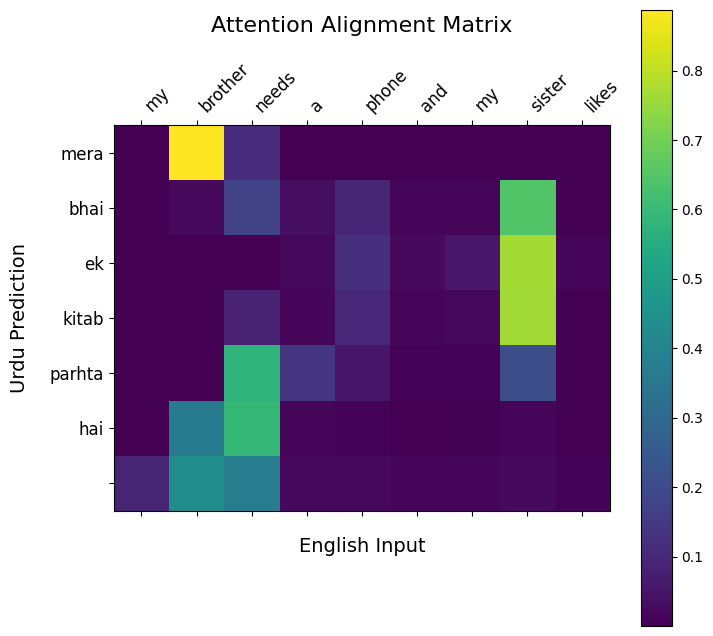

Input: my brother needs a phone and my sister likes books
Output: mera bhai ek kitab parhta hai


In [88]:

test_sentence = "my brother needs a phone and my sister likes books" # Try changing this to anything in the vocab!
translation = translate_and_plot_attention(attn_model, test_sentence)
print(f"Input: {test_sentence}")
print(f"Output: {translation}")